# Spring Grid Simulation — Time-Dependent Edition (100×100, 500 frames)

This notebook extends the original static spring-grid solver into a **dynamic**
simulation, scaled up to a **100×100** grid (10,000 DOFs) and sampled at
**500 frames**.

The static equation $K\,u = f$ becomes the time-dependent equation

$$M\,\ddot{u}(t) \;+\; C\,\dot{u}(t) \;+\; K\,u(t) \;=\; f(t)$$

integrated with the implicit **Newmark-β** scheme (γ=½, β=¼).

## 1. Imports


In [1]:
!pip install -q imageio
import os, time, zipfile
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Callable, List, Optional, Sequence, Tuple

import scipy.sparse as sp
from scipy.sparse.linalg import splu, spsolve

from PIL import Image, ImageDraw
import imageio.v2 as imageio

from IPython.display import Image as IPImage, display

## 2. Grid utilities and parameters


In [2]:
n = 100          # grid is n x n
N = n * n        # total DOFs

def idx(i, j, grid_n=n):
    # Flat (row-major) index of node (i, j).
    return i * grid_n + j

print(f'Grid: {n} x {n}  ->  {N} DOFs')


Grid: 100 x 100  ->  10000 DOFs


## 3. Sparse assembly of K, M, C

`K` is built directly in COO format from vectorised triplet arrays, then
converted to CSR. `M` is a sparse diagonal. `C` is Rayleigh damping.


In [3]:
def build_stiffness_matrix(n, seed=None):
    rng = np.random.default_rng(seed)
    rows, cols, vals = [], [], []

    def add_pairs(a, b, k):
        # Each spring contributes to 4 entries: (a,a), (b,b), (a,b), (b,a).
        rows.extend([a, b, a, b]); cols.extend([a, b, b, a])
        vals.extend([k, k, -k, -k])

    # Horizontal: (i, j) -- (i, j+1)
    i_h, j_h = np.meshgrid(np.arange(n), np.arange(n - 1), indexing='ij')
    a = (i_h * n + j_h).ravel(); b = (i_h * n + j_h + 1).ravel()
    add_pairs(a, b, rng.random(a.size))

    # Vertical: (i, j) -- (i+1, j)
    i_v, j_v = np.meshgrid(np.arange(n - 1), np.arange(n), indexing='ij')
    a = (i_v * n + j_v).ravel(); b = ((i_v + 1) * n + j_v).ravel()
    add_pairs(a, b, rng.random(a.size))

    # Diagonal: (i, j) -- (i+1, j+1)
    i_d, j_d = np.meshgrid(np.arange(n - 1), np.arange(n - 1), indexing='ij')
    a = (i_d * n + j_d).ravel(); b = ((i_d + 1) * n + j_d + 1).ravel()
    add_pairs(a, b, rng.random(a.size))

    rows = np.concatenate(rows); cols = np.concatenate(cols); vals = np.concatenate(vals)
    K = sp.coo_matrix((vals, (rows, cols)), shape=(N, N)).tocsr()
    K.sum_duplicates()
    return K


def build_mass_matrix(n, m=1.0):
    return m * sp.eye(n * n, format='csr')


def build_damping_matrix(M, K, alpha=0.05, beta=0.02):
    return (alpha * M + beta * K).tocsr()


t0 = time.perf_counter()
K = build_stiffness_matrix(n, seed=0)
M = build_mass_matrix(n)
C = build_damping_matrix(M, K, alpha=0.05, beta=0.02)
print(f'K nnz = {K.nnz}   assembly took {time.perf_counter()-t0:.2f}s')


K nnz = 69202   assembly took 0.02s


## 4. Boundary conditions and time-dependent load

Pin the bottom row; apply a sinusoidal point force at the top-centre node.


In [4]:
def get_free_dofs(n, pinned_rows=(0,)):
    pinned = [idx(i, j, n) for i in pinned_rows for j in range(n)]
    free = np.setdiff1d(np.arange(n * n), pinned)
    return pinned, free


def make_force_function(n, amplitude=1.0, omega=2 * np.pi, node=None, kind='sin'):
    # kind: 'sin', 'step', 'pulse', 'decay'
    if node is None:
        node = idx(n - 1, (n - 1) // 2, n)         # top-centre
    N = n * n
    if kind == 'sin':
        def f(t):
            out = np.zeros(N); out[node] = amplitude * np.sin(omega * t); return out
    elif kind == 'step':
        def f(t):
            out = np.zeros(N)
            if t > 0.0: out[node] = amplitude
            return out
    elif kind == 'pulse':
        T = 1.0 / max(omega, 1e-12)
        def f(t):
            out = np.zeros(N)
            if 0.0 <= t <= T: out[node] = amplitude
            return out
    elif kind == 'decay':
        def f(t):
            out = np.zeros(N)
            out[node] = amplitude * np.sin(omega * t) * np.exp(-0.5 * t)
            return out
    else:
        raise ValueError(f'Unknown kind: {kind!r}')
    return f


pinned, free = get_free_dofs(n)
force_fn = make_force_function(n, amplitude=1.0, omega=2 * np.pi, kind='sin')
print(f'Pinned: {len(pinned)} DOFs   Free: {len(free)} DOFs')


Pinned: 100 DOFs   Free: 9900 DOFs


## 5. Sparse Newmark-β time integrator

The effective stiffness $K_\text{eff} = a_0 M + a_1 C + K$ is factorised
**once** with `scipy.sparse.linalg.splu`. Each time-step is a single
back-substitution on the free DOFs.


In [21]:
@dataclass
class SimulationResult:
    times: np.ndarray
    displacements: np.ndarray   # (n_steps + 1, N)
    velocities: np.ndarray
    accelerations: np.ndarray
    n: int


def newmark_beta_simulation(K, M, C, force_fn, free, n,
                            t_end=50.0, dt=0.01, gamma=0.5, beta=0.25,
                            u0=None, v0=None):
    N = K.shape[0]
    n_steps = int(np.round(t_end / dt))
    times = np.linspace(0.0, n_steps * dt, n_steps + 1)

    Kf = K[free, :][:, free].tocsc()
    Mf = M[free, :][:, free].tocsc()
    Cf = C[free, :][:, free].tocsc()

    # Newmark integration constants.
    a0 = 1.0 / (beta * dt * dt); a1 = gamma / (beta * dt)
    a2 = 1.0 / (beta * dt);      a3 = 1.0 / (2.0 * beta) - 1.0
    a4 = gamma / beta - 1.0;     a5 = 0.5 * dt * (gamma / beta - 2.0)
    a6 = dt * (1.0 - gamma);     a7 = dt * gamma

    # Sparse LU factorisation, computed once.
    Keff = (Kf + a0 * Mf + a1 * Cf).tocsc()
    lu = splu(Keff)

    U = np.zeros((n_steps + 1, N)); V = np.zeros_like(U); A = np.zeros_like(U)
    if u0 is not None: U[0] = u0
    if v0 is not None: V[0] = v0

    # Initial acceleration: M a0 = f(0) - C v0 - K u0.
    rhs0 = force_fn(0.0)[free] - Cf @ V[0, free] - Kf @ U[0, free]
    A[0, free] = spsolve(Mf, rhs0)

    for k in range(n_steps):
        u_n, v_n, a_n = U[k, free], V[k, free], A[k, free]
        rhs = (force_fn(times[k + 1])[free]
               + Mf @ (a0 * u_n + a2 * v_n + a3 * a_n)
               + Cf @ (a1 * u_n + a4 * v_n + a5 * a_n))
        u_next = lu.solve(rhs)
        a_next = a0 * (u_next - u_n) - a2 * v_n - a3 * a_n
        v_next = v_n + a6 * a_n + a7 * a_next
        U[k + 1, free] = u_next; V[k + 1, free] = v_next; A[k + 1, free] = a_next

    return SimulationResult(times, U, V, A, n)


t0 = time.perf_counter()
result = newmark_beta_simulation(K, M, C, force_fn, free, n,
                                 t_end=50.0, dt=0.01)
print(f'Integrated {len(result.times)} steps in {time.perf_counter()-t0:.2f}s')
print(f'max |u(t)| = {np.max(np.abs(result.displacements)):.4f}')


Integrated 5001 steps in 12.33s
max |u(t)| = 0.1300


## 6. Sample 1000 frames

`sample_frames` linearly interpolates the displacement field. Pass any
of `frame_times`, `interval` (in seconds), or `n_frames` (count).


In [22]:
def sample_frames(result, frame_times=None, interval=None, n_frames=None):
    if sum(x is not None for x in (frame_times, interval, n_frames)) > 1:
        raise ValueError('Specify only one of frame_times / interval / n_frames')
    if frame_times is None and interval is None and n_frames is None:
        frame_times = result.times
    elif frame_times is None and interval is not None:
        frame_times = np.arange(result.times[0], result.times[-1] + 1e-12, interval)
    elif frame_times is None and n_frames is not None:
        frame_times = np.linspace(result.times[0], result.times[-1], n_frames)

    frame_times = np.asarray(frame_times, dtype=float)
    out = np.empty((len(frame_times), result.n, result.n))
    for k, t in enumerate(frame_times):
        j = np.searchsorted(result.times, t)
        j = int(np.clip(j, 1, len(result.times) - 1))
        t0, t1 = result.times[j - 1], result.times[j]
        w = 0.0 if t1 <= t0 else (t - t0) / (t1 - t0)
        u = (1 - w) * result.displacements[j - 1] + w * result.displacements[j]
        out[k] = u.reshape(result.n, result.n)
    return frame_times, out


times, frames = sample_frames(result, n_frames=1000)
print(f'Sampled {len(times)} frames; shape {frames.shape}')


Sampled 1000 frames; shape (1000, 100, 100)


## 7. Fast PIL/imageio renderer (GIF + PNGs)

Direct colormap → PIL → imageio. Skips matplotlib entirely so 500 frames
finish in seconds. The simulated time is burned into each image as a
small label, and the grid is upscaled 4× so individual cells are visible.


Wrote /content/spring_grid_dynamic.gif  (1298.0 KB) in 19.93s


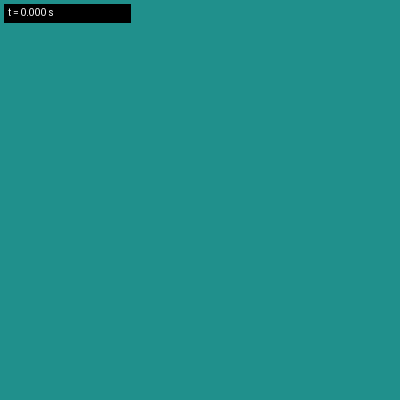

In [23]:
def frames_to_rgb(frames, cmap='viridis', vlim=None, scale=4):
    if vlim is None:
        m = float(np.max(np.abs(frames))) or 1.0
        vlim = (-m, m)
    lo, hi = vlim
    norm = ((frames - lo) / max(hi - lo, 1e-12)).clip(0, 1)
    cmap_fn = plt.colormaps.get_cmap(cmap)
    rgb = (cmap_fn(norm)[..., :3] * 255).astype(np.uint8)
    if scale > 1:
        rgb = np.repeat(np.repeat(rgb, scale, axis=1), scale, axis=2)
    return rgb


def stamp_timestamp(img, t):
    draw = ImageDraw.Draw(img)
    label = f't = {t:.3f} s'
    draw.rectangle([(4, 4), (130, 22)], fill=(0, 0, 0))
    draw.text((8, 6), label, fill=(255, 255, 255))


def render_animation(frame_times, frames, output_path, fps=30,
                     cmap='viridis', vlim=None, scale=4, stamp_time=True):
    rgb = frames_to_rgb(frames, cmap=cmap, vlim=vlim, scale=scale)
    out_imgs = []
    for k in range(rgb.shape[0]):
        img = Image.fromarray(rgb[k])
        if stamp_time:
            stamp_timestamp(img, frame_times[k])
        out_imgs.append(np.asarray(img))
    ext = os.path.splitext(output_path)[1].lower()
    if ext == '.gif':
        imageio.mimsave(output_path, out_imgs, fps=fps, loop=0)
    else:
        try:
            imageio.mimsave(output_path, out_imgs, fps=fps)
        except Exception:
            imageio.mimsave(os.path.splitext(output_path)[0] + '.gif',
                            out_imgs, fps=fps, loop=0)
    return os.path.abspath(output_path)


t0 = time.perf_counter()
gif_path = render_animation(times, frames, 'spring_grid_dynamic.gif', fps=30)
print(f'Wrote {gif_path}  ({os.path.getsize(gif_path)/1024:.1f} KB) '
      f'in {time.perf_counter()-t0:.2f}s')
display(IPImage(filename=gif_path))


### Optional MP4 export

```python
mp4_path = render_animation(times, frames, 'spring_grid_dynamic.mp4', fps=30)
# from google.colab import files; files.download(mp4_path)
```


In [24]:
mp4_path = render_animation(times, frames, 'spring_grid_dynamic.mp4', fps=30)
from google.colab import files; files.download(mp4_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7b. Save and download all 1000 frames

Each sampled frame is rendered as an individual **PNG** image and bundled
into `spring_grid_frames.zip` for one-click download in Colab.


Wrote 1000 PNGs to ./frames/
Bundled as spring_grid_frames.zip  (2174.6 KB)
Total time: 6.44s


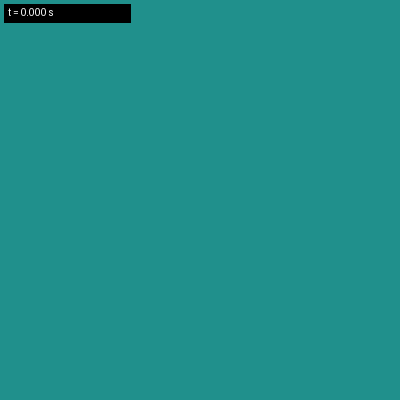

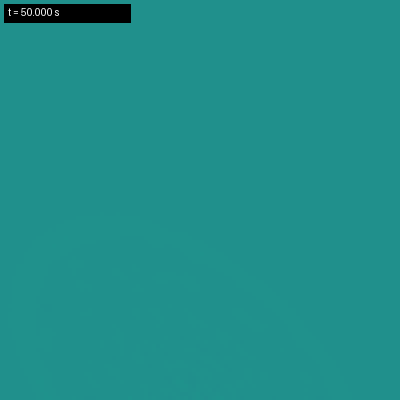

In [25]:
def save_frames_as_pngs(frame_times, frames, frames_dir='frames',
                        cmap='viridis', vlim=None, scale=4, stamp_time=True,
                        as_zip=True, zip_path='spring_grid_frames.zip'):
    os.makedirs(frames_dir, exist_ok=True)
    rgb = frames_to_rgb(frames, cmap=cmap, vlim=vlim, scale=scale)
    n_digits = max(4, len(str(len(frame_times) - 1)))
    paths = []
    for k, t in enumerate(frame_times):
        img = Image.fromarray(rgb[k])
        if stamp_time:
            stamp_timestamp(img, t)
        fname = f'frame_{k:0{n_digits}d}_t{t:08.3f}s.png'
        path = os.path.join(frames_dir, fname)
        img.save(path, optimize=False)
        paths.append(path)

    archive = None
    if as_zip:
        archive = zip_path
        with zipfile.ZipFile(archive, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
            for p in paths:
                zf.write(p, arcname=os.path.basename(p))
    print(f'Wrote {len(paths)} PNGs to ./{frames_dir}/')
    if archive:
        print(f'Bundled as {archive}  ({os.path.getsize(archive)/1024:.1f} KB)')
    return paths, archive


t0 = time.perf_counter()
png_paths, zip_path = save_frames_as_pngs(times, frames,
                                          frames_dir='frames',
                                          as_zip=True,
                                          zip_path='spring_grid_frames.zip')
print(f'Total time: {time.perf_counter()-t0:.2f}s')

# Quick visual check: first and last frames.
display(IPImage(filename=png_paths[0]))
display(IPImage(filename=png_paths[-1]))


### Download the frames

Run on Google Colab to grab the zip on your machine. Outside Colab the
zip is sitting next to the notebook — open the file browser and download
it directly.


In [26]:
try:
    from google.colab import files          # type: ignore
    files.download(zip_path)
    # Or grab a single frame:
    # files.download(png_paths[42])
except ImportError:
    print('Not running on Colab. The frames are at:')
    print(' ', os.path.abspath('frames'))
    print('And the zipped bundle is at:')
    print(' ', os.path.abspath(zip_path))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. Sanity check — original static problem

The static solver from the original notebook is preserved so you can
verify the spring-network assembly is unchanged.


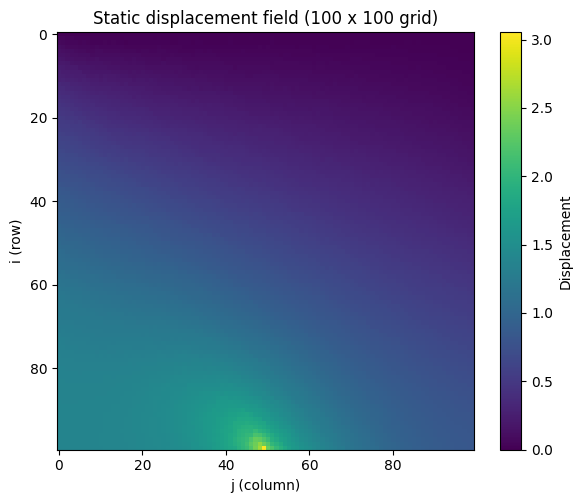

max |u| (static) = 3.0525


In [27]:
def solve_static(K, free, f):
    Kf = K[free, :][:, free].tocsc()
    u_free = spsolve(Kf, f[free])
    u = np.zeros(K.shape[0]); u[free] = u_free
    return u


f_static = np.zeros(N)
f_static[idx(n - 1, (n - 1) // 2, n)] = 1.0
u_static = solve_static(K, free, f_static)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(u_static.reshape(n, n), origin='upper', aspect='equal', cmap='viridis')
plt.colorbar(im, ax=ax, label='Displacement')
ax.set_title('Static displacement field (100 x 100 grid)')
ax.set_xlabel('j (column)'); ax.set_ylabel('i (row)')
plt.tight_layout(); plt.show()
print(f'max |u| (static) = {np.max(np.abs(u_static)):.4f}')


## 9. Trace a single node through time

Pick the loaded top-centre node and plot its displacement, velocity, and
applied load over time.


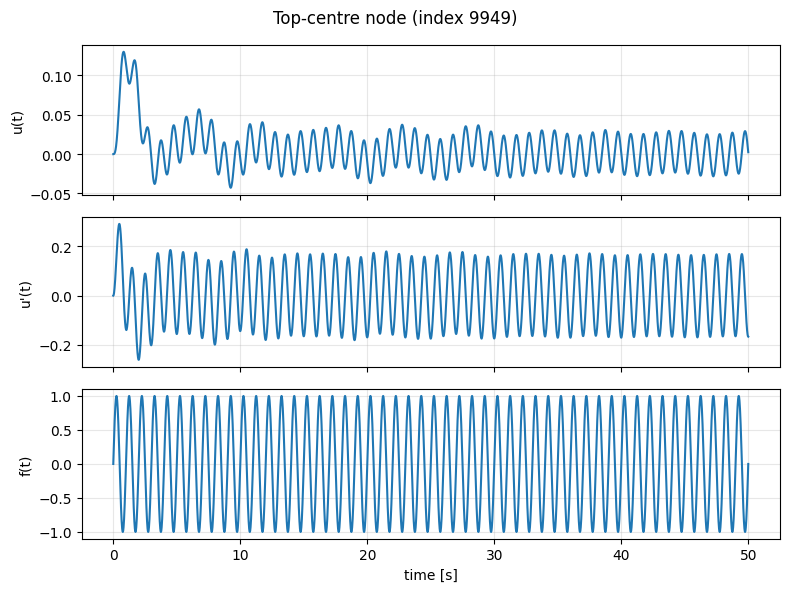

In [29]:
probe = idx(n - 1, (n - 1) // 2, n)
fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
axes[0].plot(result.times, result.displacements[:, probe]); axes[0].set_ylabel('u(t)')
axes[1].plot(result.times, result.velocities[:, probe]);    axes[1].set_ylabel("u'(t)")
axes[2].plot(result.times, [force_fn(t)[probe] for t in result.times])
axes[2].set_ylabel('f(t)'); axes[2].set_xlabel('time [s]')
for a in axes: a.grid(alpha=0.3)
plt.suptitle(f'Top-centre node (index {probe})')
plt.tight_layout(); plt.show()
